UDPLag: 1873
BENIGN: 4068

📊 Top 20 features mais correlacionadas com UDPLag:
Min Packet Length         0.918118
Fwd Packet Length Min     0.793268
Average Packet Size       0.750006
Flow Bytes/s              0.726710
Avg Fwd Segment Size      0.720739
Fwd Packet Length Mean    0.720739
Packet Length Mean        0.644196
Protocol                  0.590818
URG Flag Count            0.455502
Unnamed: 0                0.425008
Inbound                   0.420070
Destination Port          0.383125
Down/Up Ratio             0.358800
Fwd Packets/s             0.334964
Flow Packets/s            0.318914
CWE Flag Count            0.267689
Packet Length Std         0.250994
RST Flag Count            0.250658
Fwd PSH Flags             0.250658
Init_Win_bytes_forward    0.247707
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


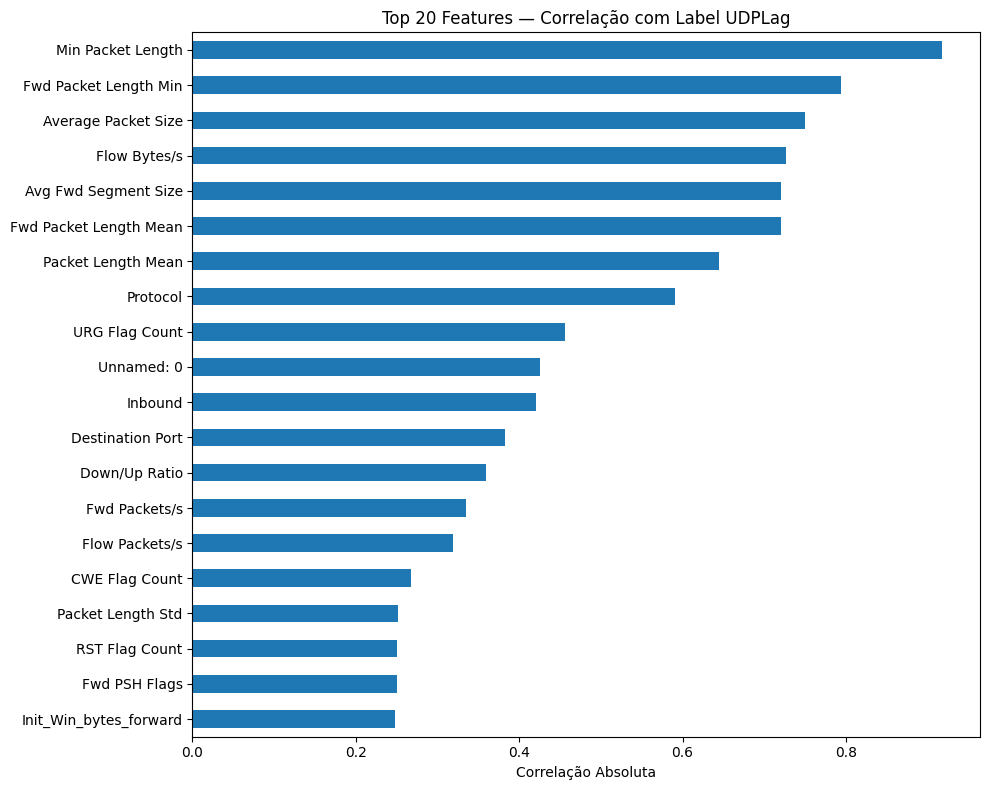

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Carregar e filtrar
# ============================
df = pd.read_csv("/content/UDPLag.csv", low_memory=False)
df.columns = df.columns.str.strip()
df = df[df["Label"].isin(["UDPLag", "BENIGN"])].copy()
df["Label"] = df["Label"].str.strip()

print(f"UDPLag: {len(df[df['Label'] == 'UDPLag'])}")
print(f"BENIGN: {len(df[df['Label'] == 'BENIGN'])}")

# ============================
# 2. Tratar NaN / inf
# ============================
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

# ============================
# 3. Matriz de correlação com o Label
# ============================
df["Label_enc"] = (df["Label"] == "UDPLag").astype(int)

correlations = df[numeric_cols].corrwith(df["Label_enc"]).abs().sort_values(ascending=False)

print("\n📊 Top 20 features mais correlacionadas com UDPLag:")
print(correlations.head(20))

plt.figure(figsize=(10, 8))
correlations.head(20).plot(kind="barh")
plt.title("Top 20 Features — Correlação com Label UDPLag")
plt.xlabel("Correlação Absoluta")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("/content/feature_correlation_udplag.png", dpi=150)
plt.show()

📊 Correlação entre as top features:
                       Min Packet Length  Fwd Packet Length Min  \
Min Packet Length                   1.00                   0.87   
Fwd Packet Length Min               0.87                   1.00   
Average Packet Size                 0.82                   0.80   
Flow Bytes/s                        0.79                   0.69   
Avg Fwd Segment Size                0.79                   0.93   

                       Average Packet Size  Flow Bytes/s  Avg Fwd Segment Size  
Min Packet Length                     0.82          0.79                  0.79  
Fwd Packet Length Min                 0.80          0.69                  0.93  
Average Packet Size                   1.00          0.78                  0.86  
Flow Bytes/s                          0.78          1.00                  0.72  
Avg Fwd Segment Size                  0.86          0.72                  1.00  


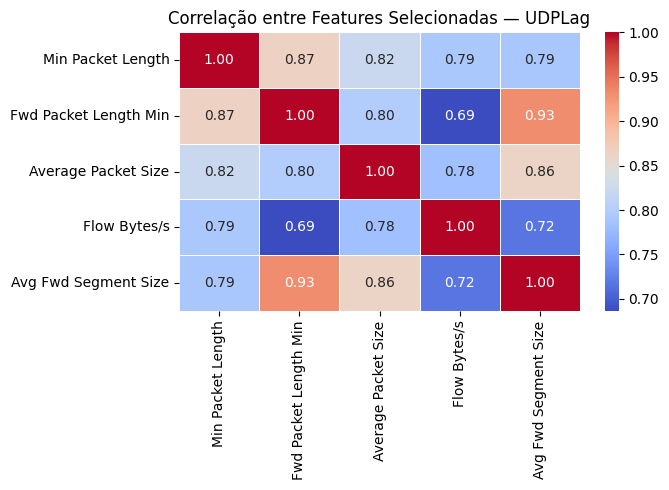

In [ ]:
# ============================
# Correlação entre as top features escolhidas
# ============================
top_features = [
    "Min Packet Length",
    "Fwd Packet Length Min",
    "Average Packet Size",
    "Flow Bytes/s",
    "Avg Fwd Segment Size"
]

corr_between = df[top_features].corr()

print("📊 Correlação entre as top features:")
print(corr_between.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_between, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre Features Selecionadas — UDPLag")
plt.tight_layout()
plt.savefig("/content/correlation_between_features_udplag.png", dpi=150)
plt.show()

In [ ]:
# Verificar próximas candidatas do ranking
candidates = [
    "Packet Length Mean",
    "URG Flag Count",
    "Down/Up Ratio",
    "Fwd Packets/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Bwd Packet Length Mean",
    "Init_Win_bytes_forward"
]

# Correlação com o label
print("📊 Correlação com o label:")
for c in candidates:
    print(f"   {c}: {correlations.get(c, 0):.3f}")

# Correlação entre candidatas e features já fixadas
fixed = ["Min Packet Length", "Flow Bytes/s", "Avg Fwd Segment Size"]
corr_check = df[fixed + candidates].corr()[fixed].loc[candidates]

print("\n📊 Correlação das candidatas com as features fixadas:")
print(corr_check.round(2))

📊 Correlação com o label:
   Packet Length Mean: 0.644
   URG Flag Count: 0.456
   Down/Up Ratio: 0.359
   Fwd Packets/s: 0.335
   Flow Packets/s: 0.319
   Flow IAT Mean: 0.121
   Flow IAT Std: 0.188
   Bwd Packet Length Mean: 0.224
   Init_Win_bytes_forward: 0.248

📊 Correlação das candidatas com as features fixadas:
                        Min Packet Length  Flow Bytes/s  Avg Fwd Segment Size
Packet Length Mean                   0.71          0.68                  0.80
URG Flag Count                      -0.50         -0.31                 -0.40
Down/Up Ratio                       -0.39         -0.35                 -0.30
Fwd Packets/s                        0.37          0.53                  0.29
Flow Packets/s                       0.35          0.51                  0.27
Flow IAT Mean                       -0.12         -0.11                 -0.10
Flow IAT Std                        -0.19         -0.17                 -0.11
Bwd Packet Length Mean              -0.22         -0.20 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold


In [ ]:

# ============================
# 1. Carregar dataset
# ============================
df = pd.read_csv("Syn.csv", low_memory=False)
df.columns = df.columns.str.strip()

print("Colunas carregadas:")
print(df.columns.tolist())


Colunas carregadas:
['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Fl

In [ ]:
# ============================
# 2. Verificar se as colunas existem
# ============================
selected_cols = [
    "Flow Duration",
    "Flow Packets/s",
    "Avg Fwd Segment Size",
    "Average Packet Size",
    "Init_Win_bytes_forward",
    "Label"
]

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    raise ValueError(f"As seguintes colunas não foram encontradas: {missing}")

In [ ]:
# ============================
# 3. Manter apenas as colunas selecionadas
# ============================
df = df[selected_cols]

In [ ]:
# ============================
# 4. Tratar NaN / inf das colunas numéricas
# ============================
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# ============================
# 5. Gerar amostra de 20%
# ============================
df_sample = df.sample(frac=0.2, random_state=42)

In [ ]:
counts = df_sample["Label"].value_counts()
print("Linhas benignas:", counts.get("BENIGN", 0))
print("Linhas malignas:", counts.sum() - counts.get("BENIGN", 0))

Linhas benignas: 7160
Linhas malignas: 856948


In [ ]:
# Quantidade de benignas (classe minoritária)
n_benign = counts.get("BENIGN", 0)

# Separar benignas e malignas
df_benign = df_sample[df_sample["Label"] == "BENIGN"]
df_malign = df_sample[df_sample["Label"] != "BENIGN"]

# Undersampling: pegar apenas n_benign linhas malignas
df_malign_sample = df_malign.sample(n=n_benign, random_state=42)

# Juntar 50% benignas + 50% malignas
df_balanced = pd.concat([df_benign, df_malign_sample], axis=0).sample(frac=1, random_state=42)

# Salvar dataset balanceado
df_balanced.to_csv("Syn_balanceado_50_50.csv", index=False)

print("📁 Dataset balanceado salvo como Syn_balanceado_50_50.csv")
print("Linhas:", len(df_balanced))
print(df_balanced["Label"].value_counts())


📁 Dataset balanceado salvo como Syn_balanceado_50_50.csv
Linhas: 14320
Label
BENIGN    7160
Syn       7160
Name: count, dtype: int64


📁 Dataset reduzido salvo como Syn_reduzido.csv
✔️ Linhas: 864108
✔️ Colunas: ['Flow Duration', 'Flow Packets/s', 'Avg Fwd Segment Size', 'Average Packet Size', 'Init_Win_bytes_forward', 'Label']


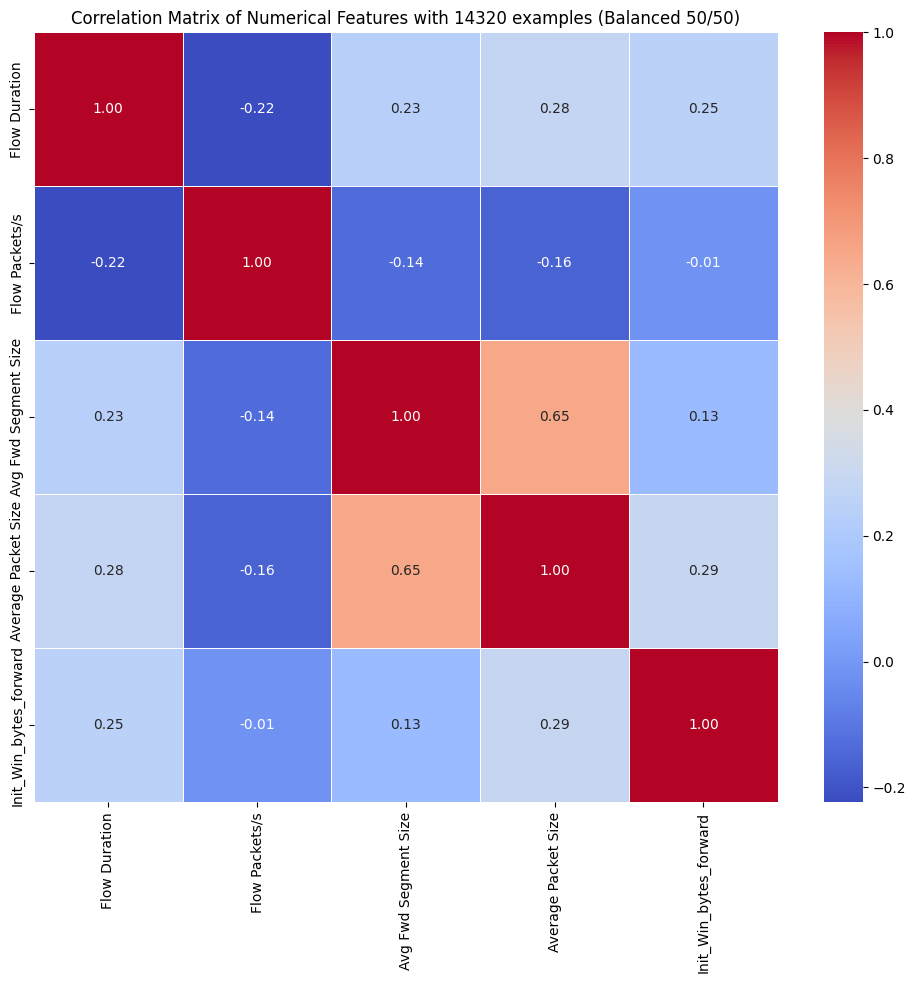

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas colunas numéricas
numeric_cols = df_balanced.select_dtypes(include=['int64', 'float64']).columns

# Gerar matriz de correlação
corr_matrix = df_balanced[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Features with 14320 examples (Balanced 50/50)")
plt.savefig("correlation_matrix_50_50.png", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
"""
generate_finetune_dataset_udplag.py
====================================
Gera dataset de finetuning no formato ChatML (Llama 3.2) para detecção de UDPLag.
Usa os labels REAIS do CSV — sem regras fixas.

Features selecionadas por análise de correlação:
  - Min Packet Length      (corr. label: 0.918)
  - Avg Fwd Segment Size   (corr. label: 0.721)
  - Flow Bytes/s           (corr. label: 0.727)
  - URG Flag Count         (corr. label: 0.456)
  - Fwd Packets/s          (corr. label: 0.335)

Saída:
  - finetune_dataset_udplag.jsonl  → 80% dos dados (treino + validação no Colab)
  - test_dataset_udplag.jsonl      → 20% dos dados (teste final, nunca visto pelo modelo)
"""

import pandas as pd
import json
import random
import statistics

# ───────────────────────────────────────────────
# CONFIGURAÇÃO
# ───────────────────────────────────────────────
CSV_PATH = "/content/UDPLag.csv"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ───────────────────────────────────────────────
# SYSTEM PROMPT
# ───────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a network security analyst specialized in detecting UDPLag DDoS attacks. "
    "Analyze network flow features and respond only with a valid JSON object containing "
    "dos_attack_probability (0-100)."
)

# ───────────────────────────────────────────────
# SCORE BASEADO NO LABEL REAL
# ───────────────────────────────────────────────
def generate_score(true_label):
    if true_label == "BENIGN":
        return 5
    else:  # UDPLag
        return 95


# ───────────────────────────────────────────────
# TEMPLATES DE PERGUNTA
# ───────────────────────────────────────────────
USER_TEMPLATES = [
    "Analyze the following network flow and determine the probability of a UDPLag DoS attack.\n\nFlow features:\n- Min Packet Length: {min_pkt} bytes\n- Avg Fwd Segment Size: {avg_fwd} bytes\n- Flow Bytes/s: {flow_bytes}\n- URG Flag Count: {urg}\n- Fwd Packets/s: {fwd_pps}\n\nRespond ONLY with JSON: {{\"dos_attack_probability\": <0-100>}}",

    "Given this network flow data, estimate the likelihood (0-100) of a UDPLag flooding attack.\n\n- Min Packet Length: {min_pkt} bytes\n- Average Forward Segment Size: {avg_fwd} bytes\n- Flow Bytes per Second: {flow_bytes}\n- URG Flag Count: {urg}\n- Forward Packets per Second: {fwd_pps}\n\nReturn only valid JSON with dos_attack_probability.",

    "You are analyzing a captured network flow. Classify it as benign or UDPLag DoS attack.\n\nFeatures:\nMin Packet Length={min_pkt}, Avg Fwd Segment Size={avg_fwd}, Flow Bytes/s={flow_bytes}, URG Flag Count={urg}, Fwd Packets/s={fwd_pps}\n\nRespond with JSON only: {{\"dos_attack_probability\": int}}",
]

def build_user_message(row):
    template = random.choice(USER_TEMPLATES)
    return template.format(
        min_pkt    = round(float(row["Min Packet Length"]), 2),
        avg_fwd    = round(float(row["Avg Fwd Segment Size"]), 2),
        flow_bytes = round(float(row["Flow Bytes/s"]), 2),
        urg        = round(float(row["URG Flag Count"]), 2),
        fwd_pps    = round(float(row["Fwd Packets/s"]), 2),
    )


# ───────────────────────────────────────────────
# MAIN
# ───────────────────────────────────────────────
def main():
    print("📂 Lendo CSV...")
    # Lê todas as colunas primeiro
    df = pd.read_csv(CSV_PATH, low_memory=False)
    df.columns = df.columns.str.strip()  # remove espaços

    # Agora seleciona as colunas
    df = df[[
        "Min Packet Length",
        "Avg Fwd Segment Size",
        "Flow Bytes/s",
        "URG Flag Count",
        "Fwd Packets/s",
        "Label"
    ]].copy()

    df["Label"] = df["Label"].astype(str).str.strip()

    # Filtrar só UDPLag e BENIGN
    df = df[df["Label"].isin(["UDPLag", "BENIGN"])].copy()

    print(f"UDPLag: {len(df[df['Label'] == 'UDPLag'])}")
    print(f"BENIGN: {len(df[df['Label'] == 'BENIGN'])}")

    # Balancear 50/50
    n = len(df[df["Label"] == "UDPLag"])  # classe minoritária
    df_udplag = df[df["Label"] == "UDPLag"]
    df_benign = df[df["Label"] == "BENIGN"].sample(n=n, random_state=RANDOM_SEED)
    df = pd.concat([df_udplag, df_benign]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"\n✅ Dataset balanceado:")
    print(f"   UDPLag: {len(df[df['Label'] == 'UDPLag'])}")
    print(f"   BENIGN: {len(df[df['Label'] == 'BENIGN'])}")

    # Tratar NaN / inf
    import numpy as np
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

    # Embaralhar
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    # ── Gerar records ──
    records = []
    errors  = 0

    for idx, row in df.iterrows():
        try:
            true_label    = row["Label"]
            prob          = generate_score(true_label)
            user_msg      = build_user_message(row)
            assistant_msg = json.dumps({"dos_attack_probability": prob})

            records.append({
                "messages": [
                    {"role": "system",    "content": SYSTEM_PROMPT},
                    {"role": "user",      "content": user_msg},
                    {"role": "assistant", "content": assistant_msg}
                ],
                "_true_label": true_label
            })

        except Exception as e:
            errors += 1
            print(f"⚠️  Erro na linha {idx}: {e}")

    # ── Split 80/20 estratificado ──
    benign_records = [r for r in records if r["_true_label"] == "BENIGN"]
    udplag_records = [r for r in records if r["_true_label"] == "UDPLag"]

    random.shuffle(benign_records)
    random.shuffle(udplag_records)

    def split80(lst):
        cut = int(len(lst) * 0.8)
        return lst[:cut], lst[cut:]

    benign_train, benign_test = split80(benign_records)
    udplag_train, udplag_test = split80(udplag_records)

    train_records = benign_train + udplag_train
    test_records  = benign_test  + udplag_test

    random.shuffle(train_records)
    random.shuffle(test_records)

    # Remover campo auxiliar
    for r in train_records + test_records:
        r.pop("_true_label", None)

    # ── Salvar ──
    with open("finetune_dataset_udplag.jsonl", "w", encoding="utf-8") as f:
        for r in train_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    with open("test_dataset_udplag.jsonl", "w", encoding="utf-8") as f:
        for r in test_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print(f"\n✅ Datasets gerados:")
    print(f"   finetune_dataset_udplag.jsonl → {len(train_records)} exemplos (treino)")
    print(f"   test_dataset_udplag.jsonl     → {len(test_records)} exemplos (teste final)")
    print(f"   Erros ignorados:                {errors}")

    print(f"\n📋 Exemplo:")
    print(json.dumps(train_records[0], indent=2, ensure_ascii=False))

    # ── Estatísticas ──
    for split_name, split_records in [("Treino", train_records), ("Teste", test_records)]:
        probs_benign, probs_udplag = [], []
        for r in split_records:
            try:
                score = json.loads(r["messages"][2]["content"])["dos_attack_probability"]
                (probs_udplag if score > 50 else probs_benign).append(score)
            except:
                pass

        print(f"\n📊 Distribuição [{split_name}]:")
        print(f"   BENIGN → {len(probs_benign)} exemplos | média score: {statistics.mean(probs_benign):.1f}")
        print(f"   UDPLag → {len(probs_udplag)} exemplos | média score: {statistics.mean(probs_udplag):.1f}")


if __name__ == "__main__":
    main()

📂 Lendo CSV...
UDPLag: 1873
BENIGN: 4068

✅ Dataset balanceado:
   UDPLag: 1873
   BENIGN: 1873

✅ Datasets gerados:
   finetune_dataset_udplag.jsonl → 2996 exemplos (treino)
   test_dataset_udplag.jsonl     → 750 exemplos (teste final)
   Erros ignorados:                0

📋 Exemplo:
{
  "messages": [
    {
      "role": "system",
      "content": "You are a network security analyst specialized in detecting UDPLag DDoS attacks. Analyze network flow features and respond only with a valid JSON object containing dos_attack_probability (0-100)."
    },
    {
      "role": "user",
      "content": "Analyze the following network flow and determine the probability of a UDPLag DoS attack.\n\nFlow features:\n- Min Packet Length: 379.0 bytes\n- Avg Fwd Segment Size: 379.0 bytes\n- Flow Bytes/s: 252666666.67\n- URG Flag Count: 0.0\n- Fwd Packets/s: 666666.67\n\nRespond ONLY with JSON: {\"dos_attack_probability\": <0-100>}"
    },
    {
      "role": "assistant",
      "content": "{\"dos_attack_p